In [ ]:
"""Smoke-test for the NEW Rossmann forecasting pipeline (hypertuning).

Runs the full feature-engineering -> target-transform -> inner-CV objective and
refit flow on a few real stores, then exercises hypertuning.optimize end-to-end
to validate the updated TimeSeriesCV(n_splits, train_size, test_size) API.
"""

import os
import logging
import warnings

import optuna
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from src import features
from src.engine.cv import TimeSeriesCV
from src.engine import hypertuning, utils

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO,
                    filename=os.path.join(C.LOG_DIR, "test_pipeline_new.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)

# Config

`config` merges the CV and study settings so `hypertuning.optimize` can read the inner-CV keys (`n_inner_splits`, `inner_train_size`, `inner_test_size`) used by the new `TimeSeriesCV` API.

In [ ]:
cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    #"inner_train_size": C.INNER_TRAIN_SIZE,
    #"inner_test_size":  C.INNER_TEST_SIZE,
    #"outer_test_size":  C.OUTER_TEST_SIZE,
    #"outer_train_size": C.OUTER_TRAIN_SIZE,
}

study_config = {
    "storage_url":           C.STORAGE_URL,
    "forecast_horizon":      C.FORECAST_HORIZON,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

# Merged config consumed by hypertuning.optimize
config = {**cv_config, **study_config}

In [11]:
""" Read the Rossmann store sales dataset and preprocess it for modeling. """
from src.preprocessing import preprocess_data


sales = pd.read_csv(r"C:/Users/m_kal/Downloads/datasets/rossmann-store-sales/train.csv")
stores = pd.read_csv(r"C:/Users/m_kal/Downloads/datasets/rossmann-store-sales/store.csv")

stores_to_use = [1, 2, 3, 4, 5, 6]
stores = stores[stores['Store'].isin(stores_to_use)]

df = preprocess_data(sales, stores)

# Feature engineering + target transform (new pipeline)

In [12]:
from src.engine.target_transformer import TargetTransformer

windows = ['7D', '14D', '30D', '60D']
lags    = [pd.DateOffset(days=i) for i in range(config['forecast_horizon'] * 3)]
diffs   = [pd.DateOffset(days=i) for i in [3, 5, 7, 14, 30]]
horizon = pd.DateOffset(days=config['forecast_horizon'])

y = (df
     .set_index(['Store', 'Date'])
     ['Sales'])

X = (df
     .set_index(['Date'])
     .groupby('Store')
     .apply(lambda df: features.compute(df, lags, diffs, windows, horizon)))

trf = TargetTransformer(forecast_horizon=pd.DateOffset(days=-config['forecast_horizon']),
                        anchor_col='lag_days_0').fit(X)

y = trf.transform(y)    # forward difference target
X = X.loc[y.index]      # align features with target

# Single-trial smoke test of `_objective`

In [13]:
from optuna.trial import FixedTrial
from src.engine.hypertuning import _objective

# gap=FORECAST_HORIZON embargoes the last `horizon` dates before each test window
# so the forward-difference target cannot leak future sales into training.
inner_cv = TimeSeriesCV(n_splits=config['n_inner_splits'],
                        train_size=config['inner_train_size'],
                        test_size=config['inner_test_size'],
                        gap=config['forecast_horizon'])

# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.7,
    'colsample_bytree': 1.0,
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}

mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                   study_name='stuff_new',
                                   study_config=config)

obj_fcn(mock_trial)

KeyError: 'inner_train_size'

# Refit + predict + inverse transform

In [ ]:
booster = hypertuning.refit(X, y, mock_trial, config)
test_dmatrix = xgb.DMatrix(X, enable_categorical=True)

preds = pd.Series(data=booster.predict(test_dmatrix), index=X.index, name='Sales')
preds = trf.inverse_transform(preds)

actuals = df.set_index(['Store', 'Date'])['Sales']
results = pd.merge(actuals, preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(results["Sales_actual"], results["Sales_predicted"])
print(f"MAE: {mae:.2f}")

MAE: 429.77


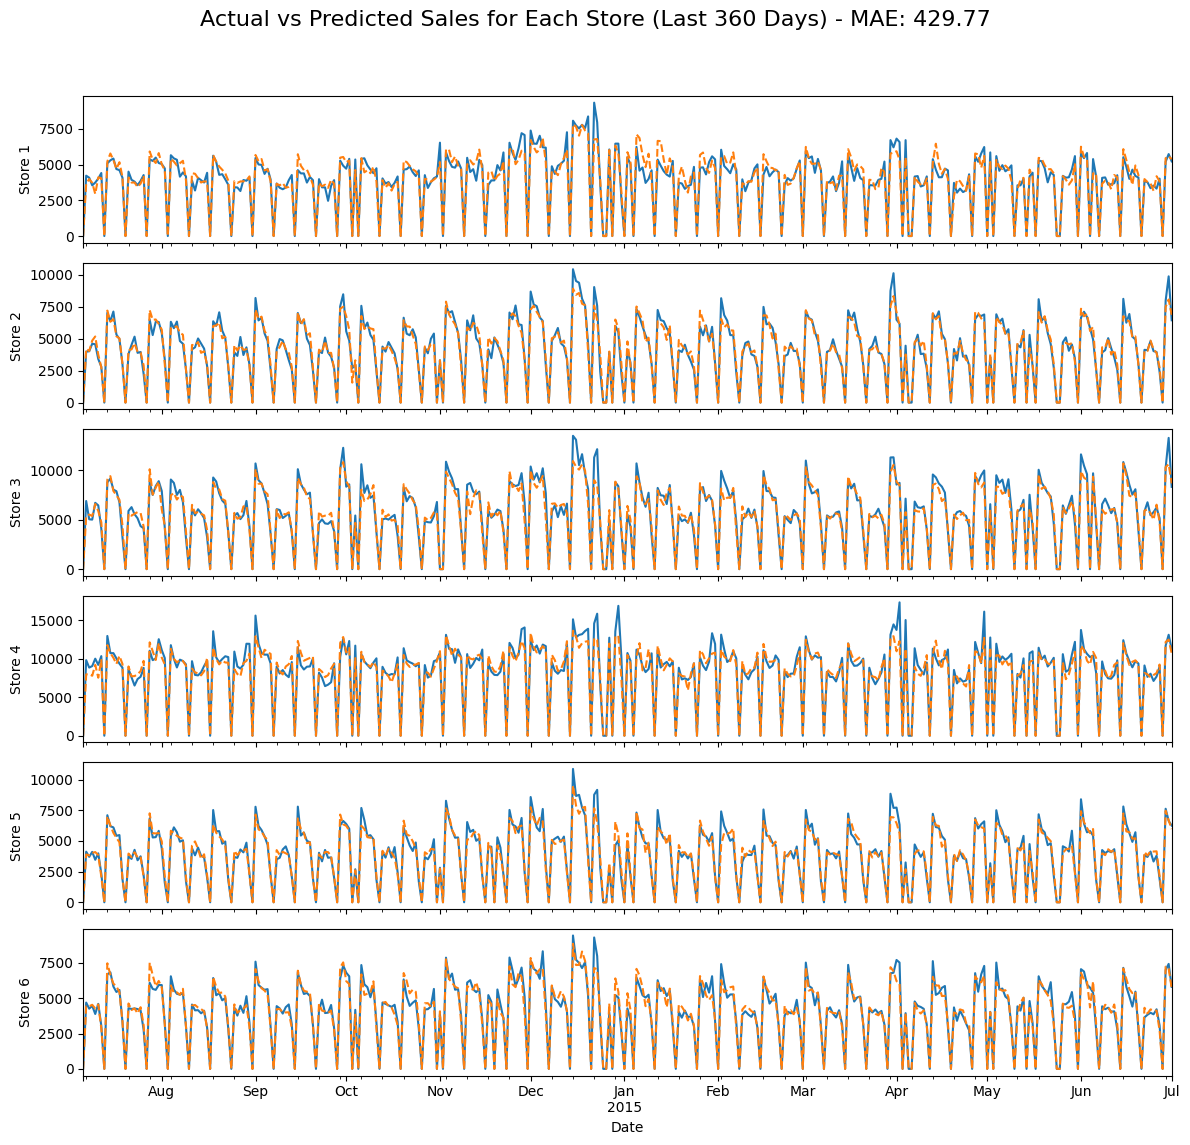

In [ ]:
n_days_to_plot = 360
n_days_offset  = 1 * 30  # Offset to start plotting from 1 month ago

max_date = results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
min_date = max_date - pd.Timedelta(days=n_days_to_plot)

actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_actual']
preds_recent   = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_predicted']

plot_stores = actuals_recent.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

for i, store in enumerate(plot_stores):

    actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
    predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()

    actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
    predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

    actual_store_sales.plot(label="Actual", ax=ax[i])
    predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")

plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days) - MAE: {:.2f}".format(n_days_to_plot, mae), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle

# End-to-end `optimize` (validates the fixed `TimeSeriesCV` API)

Runs a couple of Optuna trials through the new `optimize`. Set `n_trials` small for a quick check.

In [ ]:
# gap = FORECAST_HORIZON embargoes the inner CV inside optimize against target leakage.
hypertuning.optimize(study_name='smoke_new', X_train=X, y_train=y, config=config)

[0]	train-rmse:4.78409+0.00069	test-rmse:4.40647+0.44351
[0]	train-rmse:4.74354+0.00061	test-rmse:4.36886+0.43996
[0]	train-rmse:3.97305+0.00026	test-rmse:3.65754+0.36591
[0]	train-rmse:4.78009+0.00063	test-rmse:4.40263+0.44369
[0]	train-rmse:4.68100+0.00057	test-rmse:4.31176+0.43355
[37]	train-rmse:0.11475+0.00120	test-rmse:0.11176+0.02506
[100]	train-rmse:0.79577+0.00028	test-rmse:0.65469+0.06056
[100]	train-rmse:1.69116+0.00087	test-rmse:1.50743+0.14289
[100]	train-rmse:0.28480+0.00065	test-rmse:0.20874+0.00769
[100]	train-rmse:1.54545+0.00036	test-rmse:1.37946+0.15898
[200]	train-rmse:0.32606+0.00036	test-rmse:0.17803+0.01179
[200]	train-rmse:0.19176+0.00056	test-rmse:0.12003+0.01209
[200]	train-rmse:0.67633+0.00058	test-rmse:0.52479+0.03562
[214]	train-rmse:0.19144+0.00084	test-rmse:0.11994+0.01218
[200]	train-rmse:0.57368+0.00036	test-rmse:0.44405+0.04802
[300]	train-rmse:0.24617+0.00085	test-rmse:0.13776+0.00810
[300]	train-rmse:0.38149+0.00069	test-rmse:0.22011+0.01184
[364]	tr

# Refit with best hyperparameters and plot

Load the finished study, grab the best trial's hyperparameters, refit a model on the full `(X, y)`, then plot actual vs predicted sales per store (same style as `test_pipeline`).

In [ ]:
# Load the finished study and retrieve the best hyperparameters
study = optuna.load_study(study_name='smoke_new', storage=config["storage_url"])
best_trial = study.best_trial

print(f"Best trial: #{best_trial.number}")
print(f"Best value ({config['xgb_constants']['eval_metric']}): {best_trial.value:.6f}")
print(f"Best params: {best_trial.params}")

# Refit a model on the full dataset using the best hyperparameters
best_booster = hypertuning.refit(X, y, best_trial, config)

best_dmatrix = xgb.DMatrix(X, enable_categorical=True)
best_preds = pd.Series(data=best_booster.predict(best_dmatrix), index=X.index, name='Sales')
best_preds = trf.inverse_transform(best_preds)

actuals = df.set_index(['Store', 'Date'])['Sales']
best_results = pd.merge(actuals, best_preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))

from sklearn.metrics import mean_absolute_error
best_mae = mean_absolute_error(best_results["Sales_actual"], best_results["Sales_predicted"])
print(f"Refit MAE: {best_mae:.2f}")

Best trial: #1
Best value (rmse): 0.111347
Best params: {'max_depth': 9, 'learning_rate': 0.1790477274340389, 'subsample': 0.9921089406758696, 'colsample_bytree': 0.9950128746691576, 'min_child_weight': 4, 'reg_alpha': 0.17087057888967963, 'reg_lambda': 0.01793435221499819, 'gamma': 0.2026949995666374}
Refit MAE: 430.05


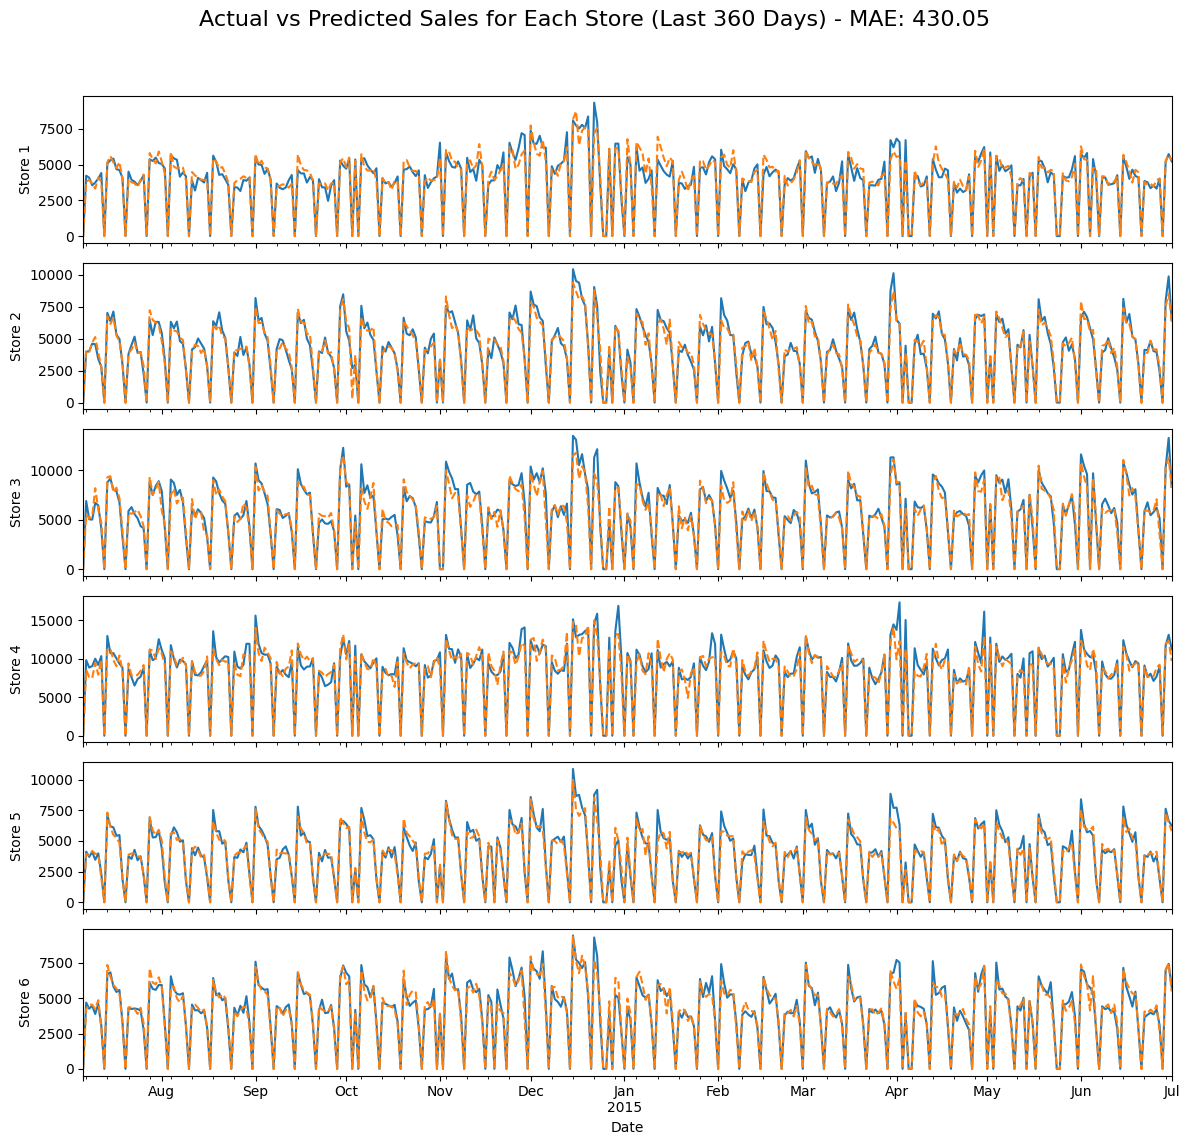

In [ ]:
n_days_to_plot = 360
n_days_offset  = 1 * 30  # Offset to start plotting from 1 month ago

max_date = best_results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
min_date = max_date - pd.Timedelta(days=n_days_to_plot)

actuals_recent = best_results.loc[(slice(None), slice(min_date, max_date)), 'Sales_actual']
preds_recent   = best_results.loc[(slice(None), slice(min_date, max_date)), 'Sales_predicted']

plot_stores = actuals_recent.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

for i, store in enumerate(plot_stores):

    actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
    predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()

    actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
    predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

    actual_store_sales.plot(label="Actual", ax=ax[i])
    predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")

plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days) - MAE: {:.2f}".format(n_days_to_plot, best_mae), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle

# Nested cross-validation (out-of-fold predictions)

Run 3 outer folds, each test window equal to `FORECAST_HORIZON` steps per store. On every outer fold we tune hyperparameters on the training portion, refit with the best params, and predict the held-out test window. The out-of-fold predictions are then collected and plotted per store.

In [7]:
from sklearn.metrics import mean_absolute_error

num_days = X.index.get_level_values("Date").nunique()
cv_sizes = utils.calculate_nested_cv_sizes(num_days, config['forecast_horizon'], config['n_outer_splits'], config['n_inner_splits'])
config.update(cv_sizes)  # Update config with calculated CV sizes

outer_cv = TimeSeriesCV(n_splits=config['n_outer_splits'],
                        train_size=config['outer_train_size'],
                        test_size=config['outer_test_size'],
                        gap=config['forecast_horizon'])

oof_preds = []
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test           = X.iloc[test_idx]

    print(f"\n=== Outer fold {fold}/{config['n_outer_splits']} | train={len(X_train)} rows, test={len(X_test)} rows ===")

    # 1) Hyperparameter tuning on the outer-fold training data (embargoed inner CV inside optimize).
    study_name = f"nested_outer_{fold}"
    hypertuning.optimize(study_name=study_name, X_train=X_train, y_train=y_train, config=config)

    # 2) Refit on the outer-fold training data using the best hyperparameters.
    study = optuna.load_study(study_name=study_name, storage=config["storage_url"])
    fold_booster = hypertuning.refit(X_train, y_train, study.best_trial, config)

    # 3) Predict the held-out test window and store the out-of-fold predictions.
    fold_dtest = xgb.DMatrix(X_test, enable_categorical=True)
    fold_preds = pd.Series(fold_booster.predict(fold_dtest), index=X_test.index, name='Sales')
    oof_preds.append(fold_preds)

# Combine all out-of-fold predictions and invert the target transform.
oof_preds = pd.concat(oof_preds)
oof_preds = trf.inverse_transform(oof_preds)

# Align the out-of-fold predictions with the actual sales.
oof_actuals = df.set_index(['Store', 'Date'])['Sales']
oof_results = pd.merge(oof_actuals, oof_preds, left_index=True, right_index=True,
                       suffixes=('_actual', '_predicted')).sort_index()

oof_mae = mean_absolute_error(oof_results["Sales_actual"], oof_results["Sales_predicted"])
print(f"\nOut-of-fold MAE: {oof_mae:.2f}")


=== Outer fold 1/5 | train=5232 rows, test=60 rows ===
[0]	train-rmse:4.47907+0.00478	test-rmse:4.87415+0.35287
[0]	train-rmse:3.87692+0.00490	test-rmse:4.20467+0.31089
[0]	train-rmse:4.22302+0.00418	test-rmse:4.59406+0.32777
[0]	train-rmse:4.71919+0.00455	test-rmse:5.13784+0.36919
[0]	train-rmse:4.67100+0.00456	test-rmse:5.08662+0.36343
[40]	train-rmse:0.22320+0.00415	test-rmse:0.25023+0.08306
[66]	train-rmse:0.15901+0.00103	test-rmse:0.16162+0.02810
[100]	train-rmse:0.27536+0.00412	test-rmse:0.24540+0.08011

=== Outer fold 2/5 | train=5232 rows, test=60 rows ===
[0]	train-rmse:4.77841+0.01187	test-rmse:5.12032+0.34018
[0]	train-rmse:4.84354+0.01204	test-rmse:5.18856+0.34444
[0]	train-rmse:4.81607+0.01200	test-rmse:5.15974+0.34260[0]	train-rmse:4.72698+0.01175	test-rmse:5.06426+0.33649

[0]	train-rmse:4.84384+0.01204	test-rmse:5.18890+0.34450
[100]	train-rmse:0.45356+0.00128	test-rmse:0.52992+0.14366
[100]	train-rmse:4.37979+0.01062	test-rmse:4.71048+0.31648
[100]	train-rmse:1.14725+

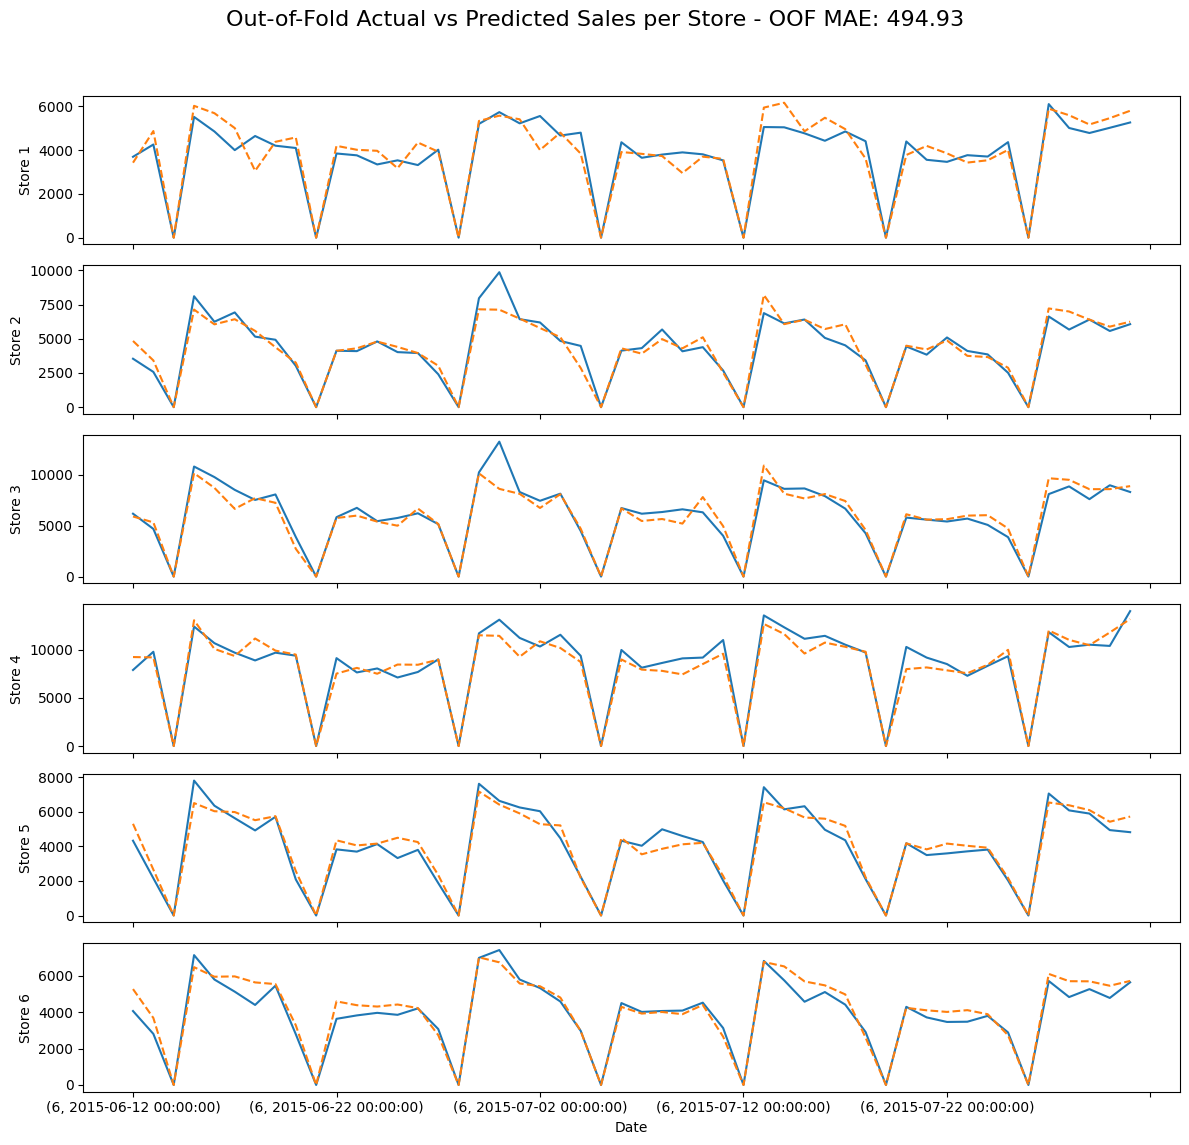

In [8]:
# Plot the out-of-fold predictions per store (same style as the earlier plots).
plot_stores = oof_results.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

for i, store in enumerate(plot_stores):

    actual_store_sales    = oof_results.loc[(store, slice(None)), 'Sales_actual'].copy()
    predicted_store_sales = oof_results.loc[(store, slice(None)), 'Sales_predicted'].copy()

    actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
    predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

    actual_store_sales.plot(label="Actual", ax=ax[i])
    predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")

plt.suptitle("Out-of-Fold Actual vs Predicted Sales per Store - OOF MAE: {:.2f}".format(oof_mae), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle